In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

In [ ]:
def plot_data(X, y, pos_label="Admitted", neg_label="Not admitted"):
  positive = y.flatten() == 1
  negative = y.flatten() == 0

  plt.plot(X[positive, 0], X[positive, 1], 'k+', label=pos_label)
  plt.plot(X[negative, 0], X[negative, 1], 'yo', label=neg_label)
  plt.xlabel("Exam 1 score")
  plt.ylabel("Exam 2 score")
  plt.legend()
  plt.show()


def load_data_multi():
    data = np.loadtxt("ex2data2.txt", delimiter=',')
    X = data[:, [0,1]]  # Tomar todas las columnas excepto la última para X
    y = data[:, [2]]   # Tomar la última columna para y
    return X, y

def map_feature(X1, X2, degree=6):
    """
    Feature mapping function to polynomial features
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    out = []
    for i in range(1, degree+1):
        for j in range(i + 1):
            out.append((X1**(i-j) * (X2**j)))
    return np.stack(out, axis=1)

def sig(z):
    return 1/(1+np.exp(-z))

def plot_decision_boundary(w, b, X, y):
    # Credit to dibgerge on Github for this plotting code
    plot_data(X[:, 0:2], y)

    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)

        plt.plot(plot_x, plot_y, c="b")

    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)

        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i, j] = sigmoid(np.dot(map_feature(u[i], v[j]), w) + b)  # Aquí utilizamos la función sigmoidal

        # important to transpose z before calling contour
        z = z.T

        # Plot z = 0
        plt.contour(u, v, z, levels=[0.5], colors="g")




In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ex2data2.txt to ex2data2.txt


In [ ]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z

    """

    g = 1 / (1 + np.exp(-z))

    return g


#########################################################################
# logistic regression
#
def compute_cost(X, y, w, b, lambda_=None):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value
      w : (array_like Shape (n,)) Values of parameters of the model
      b : scalar Values of bias parameter of the model
      lambda_: unused placeholder
    Returns:
      total_cost: (scalar)         cost
    """
    # aplicacion de la función sigmoida
    fwb = sigmoid(np.dot(X, w) + b)

    # loss function
    loss = (-y * np.log(fwb) - (1 - y) * np.log(1 - fwb))

    # Cálculo del coste total
    total_cost = np.sum(loss) / len(y)

    return total_cost


def compute_gradient(X, y, w, b, lambda_=None):
    """
    Computes the gradient for logistic regression

    Args:
      X : (ndarray Shape (m,n)) variable such as house size
      y : (array_like Shape (m,1)) actual value
      w : (array_like Shape (n,1)) values of parameters of the model
      b : (scalar)                 value of parameter of the model
      lambda_: unused placeholder
    Returns
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b.
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w.
    """
    #calculamos las prediccionesde manera vectorial
    fw_b = sigmoid(np.dot(X, w) + b)
    y = np.ravel(y)

    #calculamos los gradientes de las funciones de coste respecto a los parametros w y b
    dj_dw = (1/len(y)) * np.dot((fw_b - y), X)
    dj_db = (1/len(y)) * np.sum(fw_b - y)


    return dj_db, dj_dw



#########################################################################
# gradient descent
#
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_=None):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking
    num_iters gradient steps with learning rate alpha

    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         unused placeholder

    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
      J_history : (ndarray): Shape (num_iters,) J at each iteration,
          primarily for graphing later
    """
    #inicializamos la lista
    J_history = []

    for a in range(num_iters):
        #calculamos el gradiente con la funcion que nos pasan por parametros
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in)
        #actualizamos los parametros

        w_in -= alpha * dj_dw
        b_in -= alpha * dj_db

        #calculamos el coste con la funcion que nos pasan por parametros
        cost = cost_function(X, y, w_in, b_in)

        #añadimos el coste de cada iteracion a la lista
        J_history.append(cost)

    return w_in, b_in, J_history


#########################################################################
# predict
#
def predict(X, w, b):
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w and b

    Args:
    X : (ndarray Shape (m, n))
    w : (array_like Shape (n,))      Parameters of the model
    b : (scalar, float)              Parameter of the model

    Returns:
    p: (ndarray (m,1))
        The predictions for X using a threshold at 0.5
    """
    probabilities = sigmoid(np.dot(X, w) + b)
    p = (probabilities >= 0.5)

    return p


In [ ]:
def sigmoid_test(target):
    assert np.isclose(target(3.0), 0.9525741268224334), "Failed for scalar input"
    assert np.allclose(target(np.array([2.5, 0])), [0.92414182, 0.5]), "Failed for 1D array"
    assert np.allclose(target(np.array([[2.5, -2.5], [0, 1]])),
                       [[0.92414182, 0.07585818], [0.5, 0.73105858]]), "Failed for 2D array"
    print('\033[92mAll tests passed!')

def compute_cost_test(target):
    X = np.array([[0, 0, 0, 0]]).T
    y = np.array([0, 0, 0, 0])
    w = np.array([0])
    b = 1
    result = target(X, y, w, b)
    if math.isinf(result):
        raise ValueError("Did you get the sigmoid of z_wb?")

    np.random.seed(17)
    X = np.random.randn(5, 2)
    y = np.array([1, 0, 0, 1, 1])
    w = np.random.randn(2)
    b = 0
    result = target(X, y, w, b)
    assert np.isclose(result, 2.15510667), f"Wrong output. Expected: {2.15510667} got: {result}"

    X = np.random.randn(4, 3)
    y = np.array([1, 1, 0, 0])
    w = np.random.randn(3)
    b = 0

    result = target(X, y, w, b)
    assert np.isclose(result, 0.80709376), f"Wrong output. Expected: {0.80709376} got: {result}"

    X = np.random.randn(4, 3)
    y = np.array([1, 0,1, 0])
    w = np.random.randn(3)
    b = 3
    result = target(X, y, w, b)
    assert np.isclose(result, 0.4529660647), f"Wrong output. Expected: {0.4529660647} got: {result}. Did you inizialized z_wb = b?"

    print('\033[92mAll tests passed!')

def compute_gradient_test(target):
    np.random.seed(1)
    X = np.random.randn(7, 3)
    y = np.array([1, 0, 1, 0, 1, 1, 0])
    test_w = np.array([1, 0.5, -0.35])
    test_b = 1.7
    dj_db, dj_dw  = target(X, y, test_w, test_b)

    assert np.isclose(dj_db, 0.28936094), f"Wrong value for dj_db. Expected: {0.28936094} got: {dj_db}"
    assert dj_dw.shape == test_w.shape, f"Wrong shape for dj_dw. Expected: {test_w.shape} got: {dj_dw.shape}"
    assert np.allclose(dj_dw, [-0.11999166, 0.41498775, -0.71968405]), f"Wrong values for dj_dw. Got: {dj_dw}"

    print('\033[92mAll tests passed!')

def predict_test(target):
    np.random.seed(5)
    b = 0.5
    w = np.random.randn(3)
    X = np.random.randn(8, 3)

    result = target(X, w, b)
    wrong_1 = [1., 1., 0., 0., 1., 0., 0., 1.]
    expected_1 = [1., 1., 1., 0., 1., 0., 0., 1.]
    if np.allclose(result, wrong_1):
        raise ValueError("Did you apply the sigmoid before applying the threshold?")
    assert result.shape == (len(X),), f"Wrong length. Expected : {(len(X),)} got: {result.shape}"
    assert np.allclose(result, expected_1), f"Wrong output: Expected : {expected_1} got: {result}"

    b = -1.7
    w = np.random.randn(4) + 0.6
    X = np.random.randn(6, 4)

    result = target(X, w, b)
    expected_2 = [0., 0., 0., 1., 1., 0.]
    assert result.shape == (len(X),), f"Wrong length. Expected : {(len(X),)} got: {result.shape}"
    assert np.allclose(result,expected_2), f"Wrong output: Expected : {expected_2} got: {result}"

    print('\033[92mAll tests passed!')

def compute_cost_reg_test(target):
    np.random.seed(1)
    w = np.random.randn(3)
    b = 0.4
    X = np.random.randn(6, 3)
    y = np.array([0, 1, 1, 0, 1, 1])
    lambda_ = 0.1
    expected_output = target(X, y, w, b, lambda_)

    assert np.isclose(expected_output, 0.5469746792761936), f"Wrong output. Expected: {0.5469746792761936} got:{expected_output}"

    w = np.random.randn(5)
    b = -0.6
    X = np.random.randn(8, 5)
    y = np.array([1, 0, 1, 0, 0, 1, 0, 1])
    lambda_ = 0.01
    output = target(X, y, w, b, lambda_)
    assert np.isclose(output, 1.2608591964119995), f"Wrong output. Expected: {1.2608591964119995} got:{output}"

    w = np.array([2, 2, 2, 2, 2])
    b = 0
    X = np.zeros((8, 5))
    y = np.array([0.5] * 8)
    lambda_ = 3
    output = target(X, y, w, b, lambda_)
    expected = -np.log(0.5) + 3. / (2. * 8.) * 20.
    assert np.isclose(output, expected), f"Wrong output. Expected: {expected} got:{output}"

    print('\033[92mAll tests passed!')

def compute_gradient_reg_test(target):
    np.random.seed(1)
    w = np.random.randn(5)
    b = 0.2
    X = np.random.randn(7, 5)
    y = np.array([0, 1, 1, 0, 1, 1, 0])
    lambda_ = 0.1
    expected1 = (-0.1506447567869257, np.array([ 0.19530838, -0.00632206,  0.19687367,  0.15741161,  0.02791437]))
    dj_db, dj_dw = target(X, y, w, b, lambda_)

    assert np.isclose(dj_db, expected1[0]), f"Wrong dj_db. Expected: {expected1[0]} got: {dj_db}"
    assert np.allclose(dj_dw, expected1[1]), f"Wrong dj_dw. Expected: {expected1[1]} got: {dj_dw}"


    w = np.random.randn(7)
    b = 0
    X = np.random.randn(7, 7)
    y = np.array([1, 0, 0, 0, 1, 1, 0])
    lambda_ = 0
    expected2 = (0.02660329857573818, np.array([ 0.23567643, -0.06921029, -0.19705212, -0.0002884 ,  0.06490588,
        0.26948175,  0.10777992]))
    dj_db, dj_dw = target(X, y, w, b, lambda_)
    assert np.isclose(dj_db, expected2[0]), f"Wrong dj_db. Expected: {expected2[0]} got: {dj_db}"
    assert np.allclose(dj_dw, expected2[1]), f"Wrong dj_dw. Expected: {expected2[1]} got: {dj_dw}"

    print('\033[92mAll tests passed!')


In [ ]:
sigmoid_test(sigmoid)

All tests passed!


In [ ]:
compute_cost_test(compute_cost)

All tests passed!


In [ ]:
compute_gradient_test(compute_gradient)

All tests passed!


In [ ]:
predict_test(predict)

All tests passed!


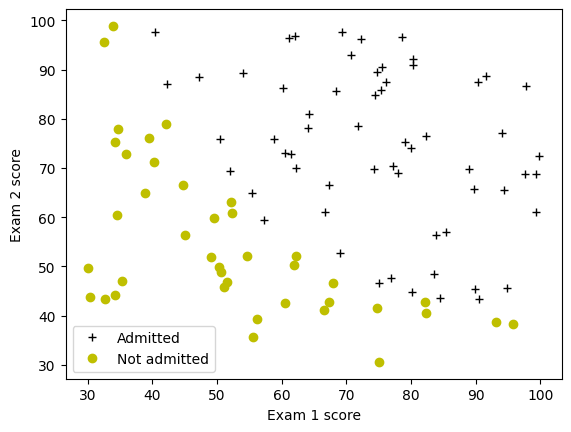

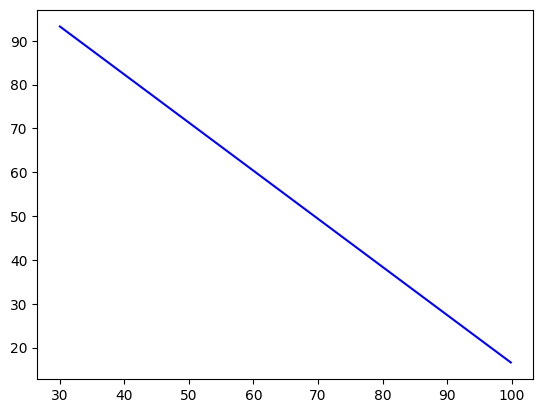

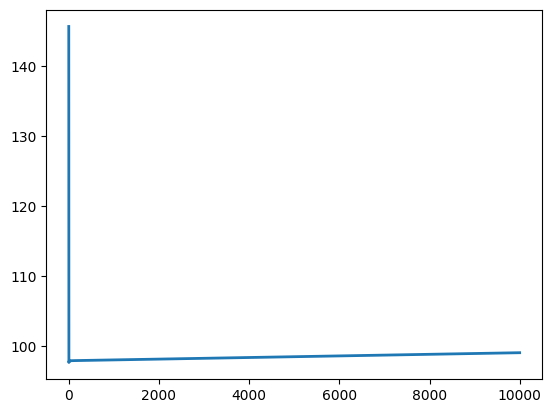

99.06757582119702


In [ ]:
# Datos de entrenamiento
X_train, y_train = load_data_multi()

#inicializamos variables
w_initial = np.zeros(2)
b_initial = -8
alpha =0.001
num_iters = 10000
# Entrenamiento del modelo
w_trained, b_trained, J_hist = gradient_descent(X_train, y_train, w_initial, b_initial, compute_cost, compute_gradient, alpha, num_iters)


#dibujamos datos reales y datos predichos
plot_decision_boundary(w_trained,b_trained, X_train, y_train)
#Dibujamos grafica de Jhistory y num iteraciones
fig, ax = plt.subplots()
ax.plot(J_hist, linewidth=2.0)
plt.show()


In [ ]:
predictions = predict(X_train, w_trained, b_trained)

# Calculamos la precisión
accuracy = np.mean(predictions == y_train) * 100
print("Precisión en el conjunto de entrenamiento:" + str(accuracy))

Precisión en el conjunto de entrenamiento:52.800000000000004


In [63]:
#########################################################################
# regularized logistic regression
#
def compute_cost_reg(X, y, w, b, lambda_=1):
    """
    Computes the cost over all examples
    Args:
      X : (array_like Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value
      w : (array_like Shape (n,)) Values of parameters of the model
      b : (array_like Shape (n,)) Values of bias parameter of the model
      lambda_ : (scalar, float)    Controls amount of regularization
    Returns:
      total_cost: (scalar)         cost
    """
    m = len(y)  # número de ejemplos de entrenamiento
    n = len(w)  # número de características

    # aplicacion de la función sigmoida
    fwb = sigmoid(np.dot(X, w) + b)

    # loss function
    loss = (-y * np.log(fwb) - (1 - y) * np.log(1 - fwb))

    # término de regularización
    regularization_term = (lambda_ / (2 * m)) * np.sum(w**2)

    # Cálculo del coste total
    total_cost = np.sum(loss) / m + regularization_term

    return total_cost


def compute_gradient_reg(X, y, w, b, lambda_=1):
    """
    Computes the gradient for linear regression

    Args:
      X : (ndarray Shape (m,n))   variable such as house size
      y : (ndarray Shape (m,))    actual value
      w : (ndarray Shape (n,))    values of parameters of the model
      b : (scalar)                value of parameter of the model
      lambda_ : (scalar,float)    regularization constant
    Returns
      dj_db: (scalar)             The gradient of the cost w.r.t. the parameter b.
      dj_dw: (ndarray Shape (n,)) The gradient of the cost w.r.t. the parameters w.

    """
    m = len(y)  # número de ejemplos de entrenamiento
    n = len(w)  # número de características

    # calculamos las predicciones
    fw_b = sigmoid(np.dot(X, w) + b)
    y = np.ravel(y)
    # calculamos los gradientes de las funciones de costo respecto a los parámetros w y b
    dj_dw = (1 / m) * np.dot((fw_b - y), X)
    dj_db = (1 / m) * np.sum(fw_b - y)

    # término de regularización para los gradientes de los parámetros w
    regularization_term = (lambda_ / m) * w

    # añadimos el término de regularización a los gradientes para los parámetros w
    dj_dw += regularization_term

    return dj_db, dj_dw


In [ ]:
compute_cost_reg_test(compute_cost_reg)

All tests passed!


In [ ]:
compute_gradient_reg_test(compute_gradient_reg)

All tests passed!


In [ ]:
# Datos de entrenamiento
X_train, y_train = load_data_multi()

X_train = map_feature(X_train[:,[0]], X_train[:,[1]])
print(np.shape(X_train))

#inicializamos variables
w_initial = np.zeros(1)
b_initial = 1
alpha = 0.01
num_iters = 100000
# Entrenamiento del modelo
w_trained, b_trained, J_hist = gradient_descent(X_train, y_train, w_initial, b_initial, compute_cost_reg, compute_gradient_reg, alpha, num_iters, 0.01)


#dibujamos datos reales y datos predichos
plot_decision_boundary(w_trained,b_trained, X_train, y_train)
#Dibujamos grafica de Jhistory y num iteraciones
fig, ax = plt.subplots()
ax.plot(J_hist, linewidth=2.0)
plt.show()


(118, 27, 1)


ValueError: operands could not be broadcast together with shapes (118,27) (118,) 

In [ ]:
# Predicciones
predictions = predict(X_train, w_trained, b_trained)

# Calculamos la precisión
accuracy = np.mean(predictions == y_train) * 100
print("Precisión en el conjunto de entrenamiento: " + str(accuracy))


ValueError: shapes (118,27,1) and (2,) not aligned: 1 (dim 2) != 2 (dim 0)